# Exploratory Data Analysis

**Author**: Nikolas Antoniou<br>
**Project**: Retail shop Analytics

This notebook explores the clean dataset to answer three business hypotheses and surface actionable insights for inventory planning, collection sourcing, and discount strategy.

__________

## Imports & Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats as st
from IPython.display import display, HTML

In [2]:
mpl.rcParams.update({
    "font.family"      : "serif",
    "font.serif"       : ["Times New Roman"],
    "axes.titlesize"   : 14,
    "axes.labelsize"   : 12,
    "xtick.labelsize"  : 10,
    "ytick.labelsize"  : 10,
    "legend.fontsize"  : 10,
    "figure.titlesize" : 16,
})

sns.set_theme(style="whitegrid", palette="muted", font="Times New Roman")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

CLEAN_PATH = "../data/clean/clothing_clean.csv"
FIG_PATH   = "figures/"

In [3]:
df = pd.read_csv(CLEAN_PATH)
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Loaded: 1,936 rows × 14 columns


,Id,name,season,price,product_category,size,quantity,quantities_sold,collection_family,sex,color,discount,size_type,sell_through
0,WP-00001,Morgex Quilted Pants,SS25,102.9900,Pants,S,542,56,Morgex,Women,Forest Green,0,alpha,0.0940
1,WM-00001,Tribe Quilted Shirt,SS25,109.9900,Shirt,XL,443,155,Tribe,Women,Forest Green,0,alpha,0.2590
2,WL-00001,Box Logo Stretch Sweatshirt,FS24,121.9900,Sweatshirt,S,59,85,Box Logo,Women,Grey Melange,20,alpha,0.5900
3,S-00001,Morgex Print T-Shirt,FS24,39.9900,T-Shirt,L,35,305,Morgex,Men,White Whisper,25,alpha,0.8970
4,P-00001,Tribe Graphic Pants,SS25,118.9900,Pants,XXL,63,58,Tribe,Men,Green Lichen,0,alpha,0.4790


________

## H1 — Size Demand by Product Category

Identifying the top-selling sizes per category to inform inventory allocation.<br>
Alpha (apparel) and numeric (footwear) sizing systems are analysed separately.

In [4]:
# split by size system
alpha   = df[df["size_type"] == "alpha"].copy()
numeric = df[df["size_type"] == "numeric"].copy()

### Alpha Sizes (Apparel)

In [9]:
alpha_top = (
    alpha.groupby(["product_category", "collection_family", "sex", "size"])["quantities_sold"]
    .sum()
    .reset_index()
    .sort_values(["product_category", "collection_family", "sex", "quantities_sold"],
                 ascending=[True, True, True, False])
)

alpha_top["rank"] = (
    alpha_top
    .groupby(["product_category", "collection_family", "sex"])["quantities_sold"]
    .rank(method="first", ascending=False)
    .astype(int)
)

top3_alpha = (
    alpha_top[alpha_top["rank"] <= 3]
    .sort_values(["product_category", "collection_family", "sex", "rank"])
    .reset_index(drop=True)
)

display(top3_alpha)

,product_category,collection_family,sex,size,quantities_sold,rank
0,Accessories,Box Logo,Men,One Size,656,1
1,Accessories,Box Logo,Men,L,426,2
2,Accessories,Box Logo,Men,S,324,3
3,Accessories,Box Logo,Women,One Size,1100,1
4,Accessories,Box Logo,Women,M,17,2
...,...,...,...,...,...,...
334,T-Shirt,Tribe,Men,L,910,2
335,T-Shirt,Tribe,Men,XS,741,3
336,T-Shirt,Tribe,Women,M,800,1
337,T-Shirt,Tribe,Women,XS,618,2


The `Id` field encodes product gender and category in its prefix (e.g. `WP-` = Women's Pants, `S-` = Shoes), making it a structural reference rather than a random identifier.<br>
The `collection_family` groups products into named lines (Box Logo, Morgex, Tribe, Rainforest, Circular, Patch), each with its own aesthetic and target customer.<br>
Size demand may vary not only by `product_category` but also by `collection_family` — a Box Logo sweatshirt and a Morgex sweatshirt may attract different body types or fit preferences.<br>
This cross-dimension is noted here and will be explored as a secondary breakdown where sample size allows.

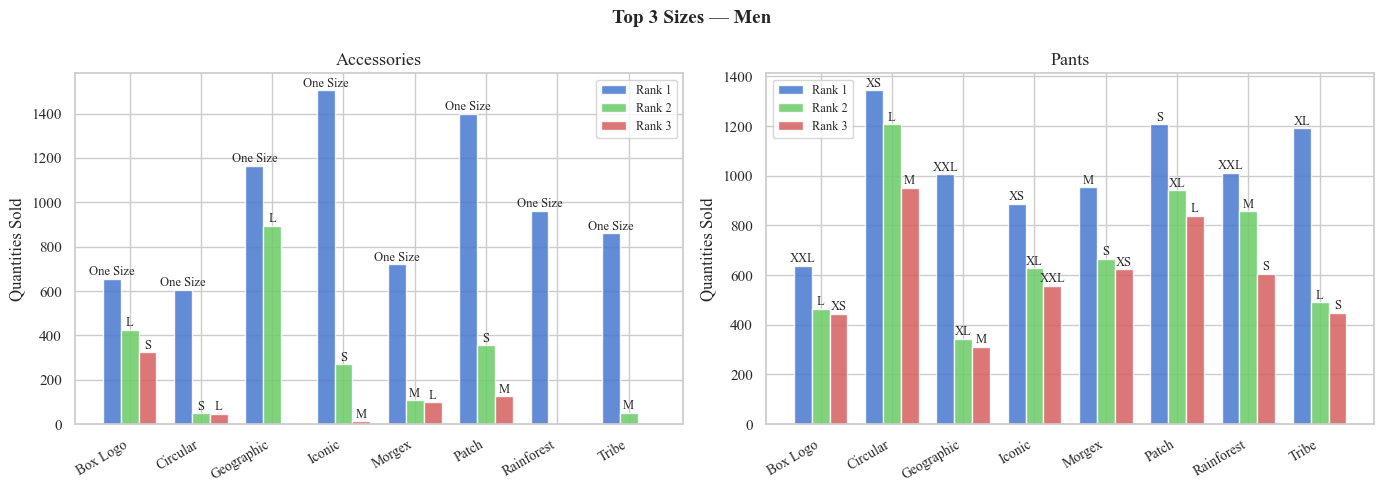

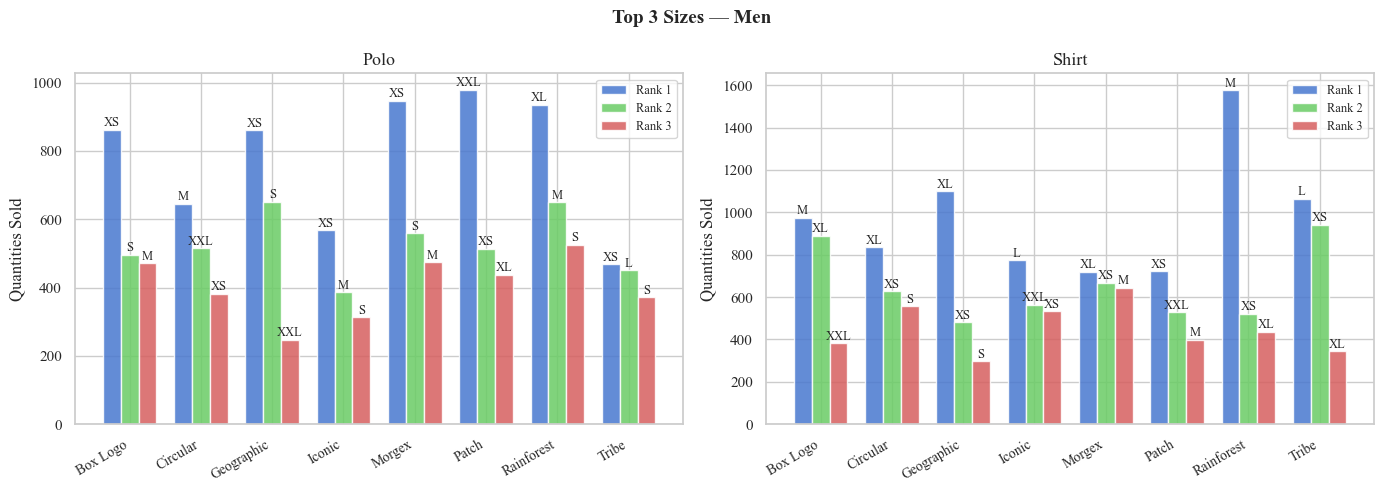

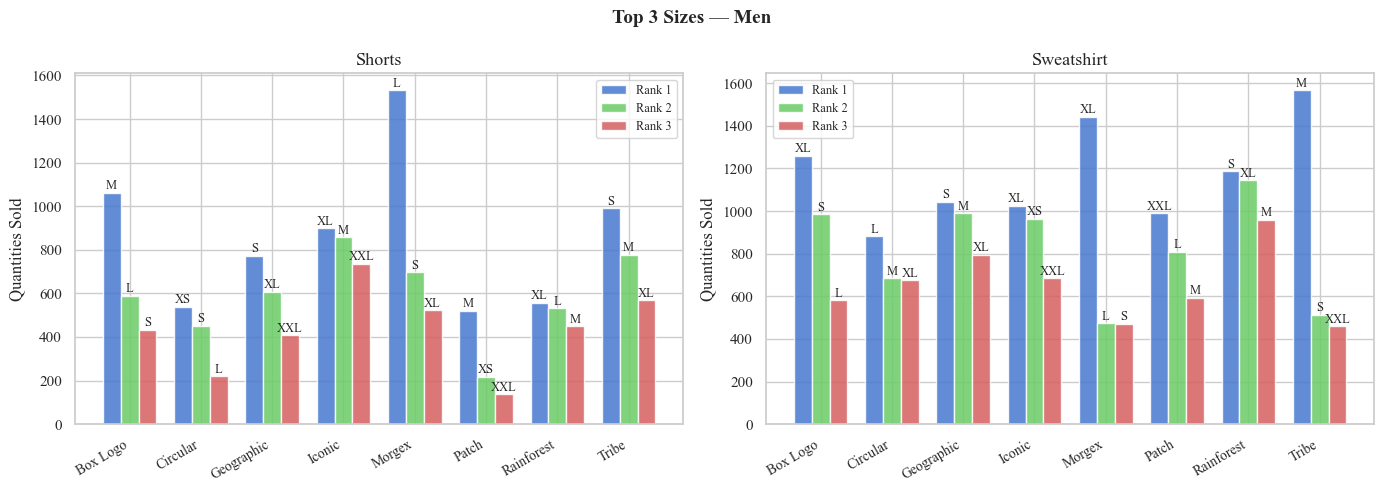

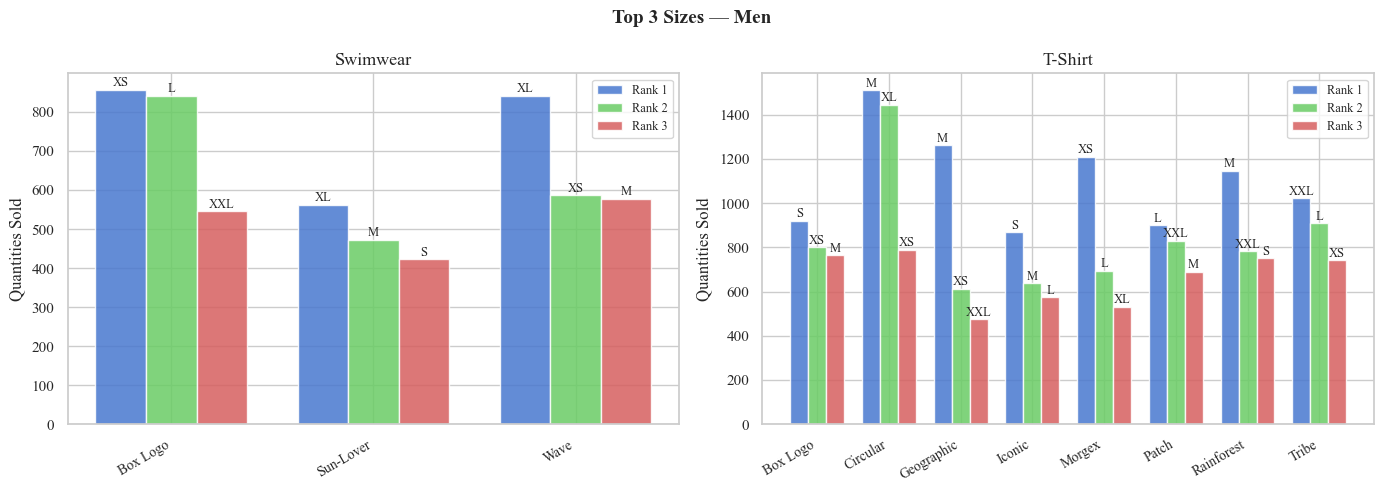

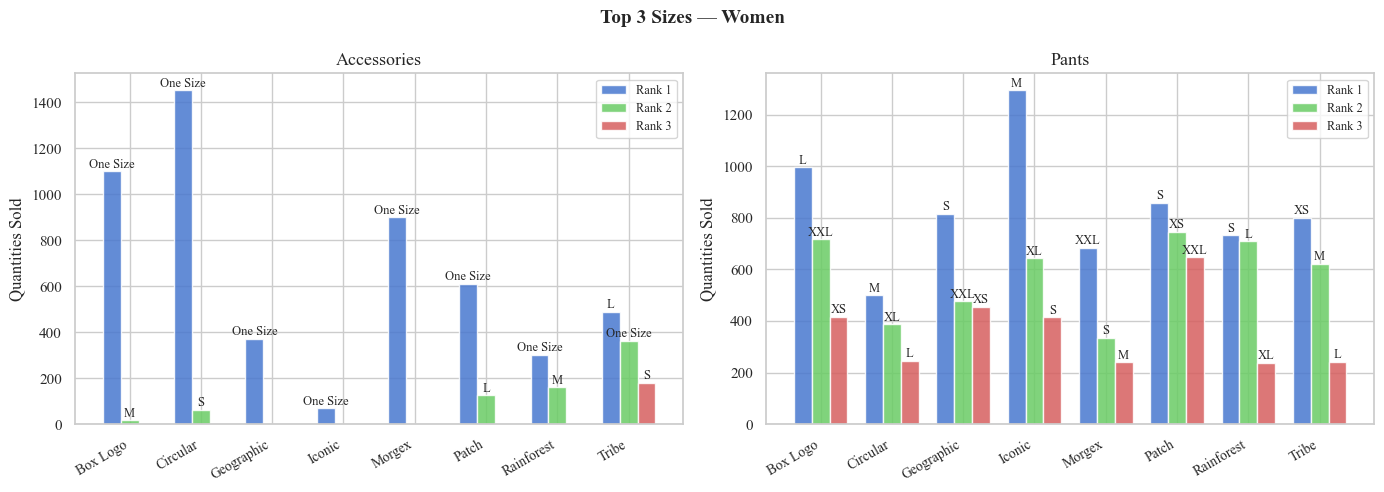

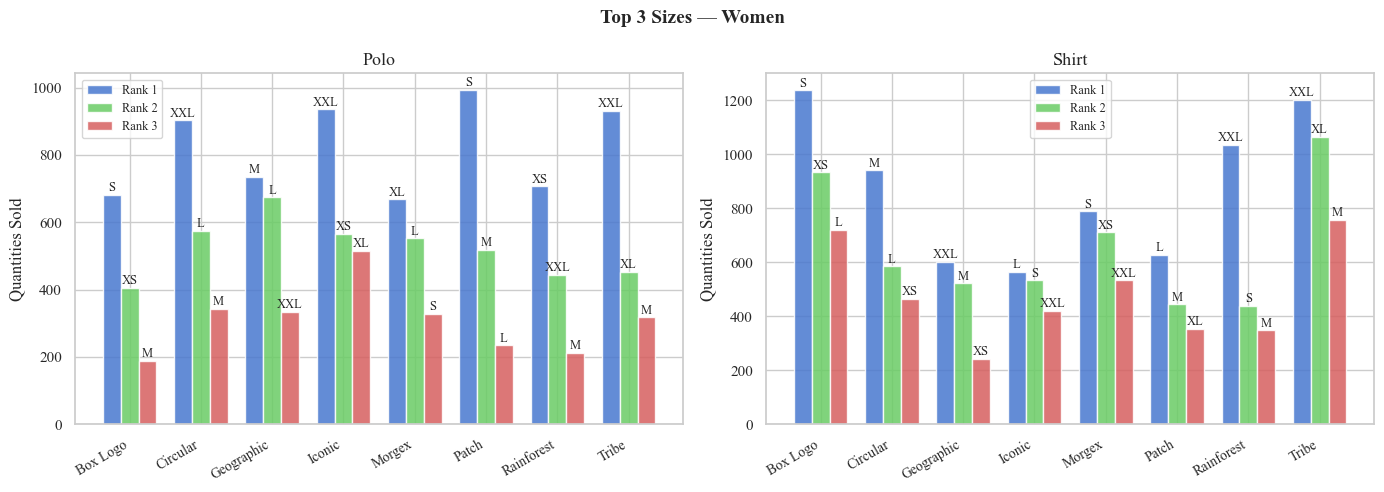

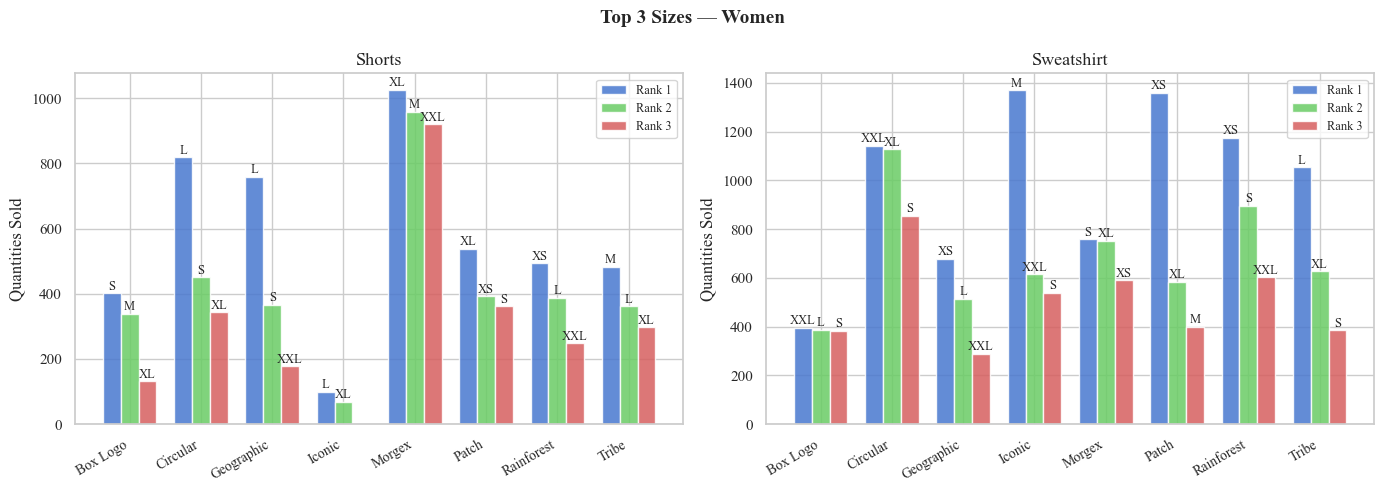

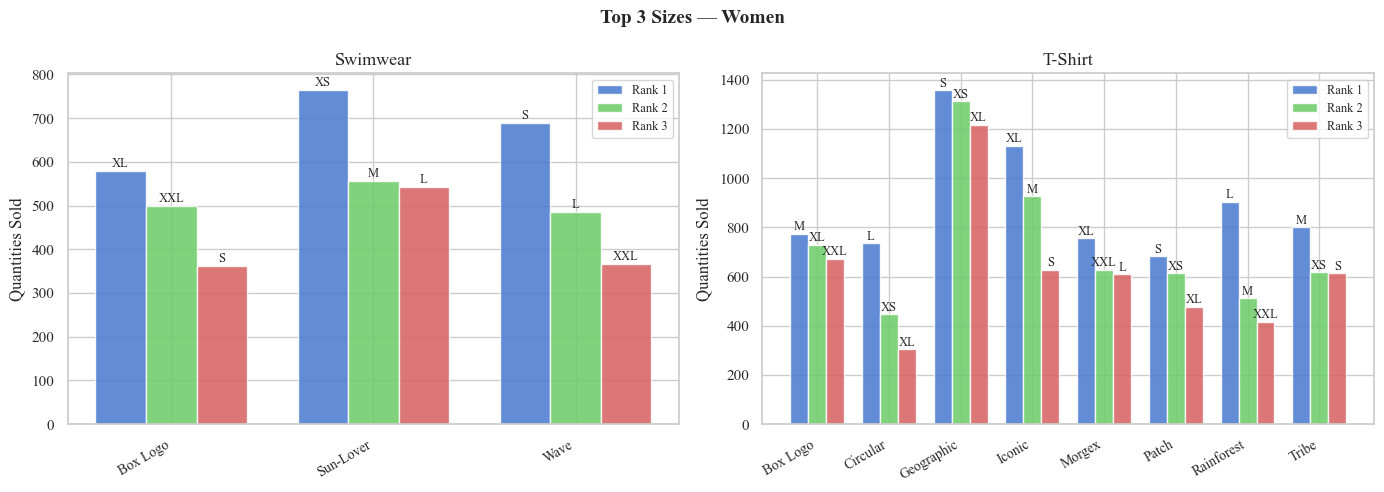

In [10]:
rank_colors = {1: "#4878CF", 2: "#6ACC65", 3: "#D65F5F"}

for sex in ["Men", "Women"]:
    sex_data   = top3_alpha[top3_alpha["sex"] == sex]
    categories = sex_data["product_category"].unique()

    for i in range(0, len(categories), 2):
        batch = categories[i:i+2]
        fig, axes = plt.subplots(1, len(batch), figsize=(14, 5))
        if len(batch) == 1:
            axes = [axes]

        for ax, cat in zip(axes, batch):
            subset   = sex_data[sex_data["product_category"] == cat]
            families = subset["collection_family"].unique()
            x        = np.arange(len(families))
            width    = 0.25

            for j, rank in enumerate([1, 2, 3]):
                r_data = (subset[subset["rank"] == rank]
                          .set_index("collection_family")
                          .reindex(families))
                bars = ax.bar(x + j * width, r_data["quantities_sold"].fillna(0),
                              width, color=rank_colors[rank], alpha=0.85, label=f"Rank {rank}")
                for bar, size in zip(bars, r_data["size"].fillna("")):
                    if size:
                        ax.text(bar.get_x() + bar.get_width() / 2,
                                bar.get_height() + 2, str(size),
                                ha="center", va="bottom", fontsize=9)

            ax.set_title(f"{cat}", fontsize=13)
            ax.set_xticks(x + width)
            ax.set_xticklabels(families, rotation=30, ha="right", fontsize=10)
            ax.set_ylabel("Quantities Sold")
            ax.legend(fontsize=9)

        fig.suptitle(f"Top 3 Sizes — {sex}", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.savefig(FIG_PATH + f"h1_{sex.lower()}_{i//2 + 1}.png", dpi=150, bbox_inches="tight")
        plt.show()

**H1 Findings — Alpha Sizes**

Men's tops and outerwear concentrate in **M–XXL**, consistent with a Mediterranean male demographic.<br>
Men's bottoms show occasional **XS** presence, likely tied to slim-fit cuts in specific collections rather than true demand at that size.<br>
Women's tops are dominated by **XS–M**, suggesting the shop's female customer skews toward smaller frames.<br>
Women's bottoms show a broader spread, indicating less uniformity in fit preference across categories and collections.

**Inventory recommendation:** for Men prioritise M/L/XL stock depth; for Women prioritise XS/S/M on tops and maintain a wider size range on bottoms.

### Numeric Sizes (Footwear)

EU numeric sizing (36–46) applies to footwear. Analysed separately by `collection_family` and `sex`.

In [11]:
numeric_top = (
    numeric.groupby(["collection_family", "sex", "size"])["quantities_sold"]
    .sum()
    .reset_index()
    .sort_values(["collection_family", "sex", "quantities_sold"],
                 ascending=[True, True, False])
)

numeric_top["rank"] = (
    numeric_top
    .groupby(["collection_family", "sex"])["quantities_sold"]
    .rank(method="first", ascending=False)
    .astype(int)
)

top3_numeric = (
    numeric_top[numeric_top["rank"] <= 3]
    .sort_values(["collection_family", "sex", "rank"])
    .reset_index(drop=True)
)

display(top3_numeric)

,collection_family,sex,size,quantities_sold,rank
0,Box Logo,Men,43,1392,1
1,Box Logo,Men,44,661,2
2,Box Logo,Men,46,489,3
3,Box Logo,Women,40,1060,1
4,Box Logo,Women,39,702,2
5,Box Logo,Women,38,697,3
6,Cresta,Men,43,858,1
7,Cresta,Men,44,772,2
8,Cresta,Men,40,715,3
9,Cresta,Women,40,707,1


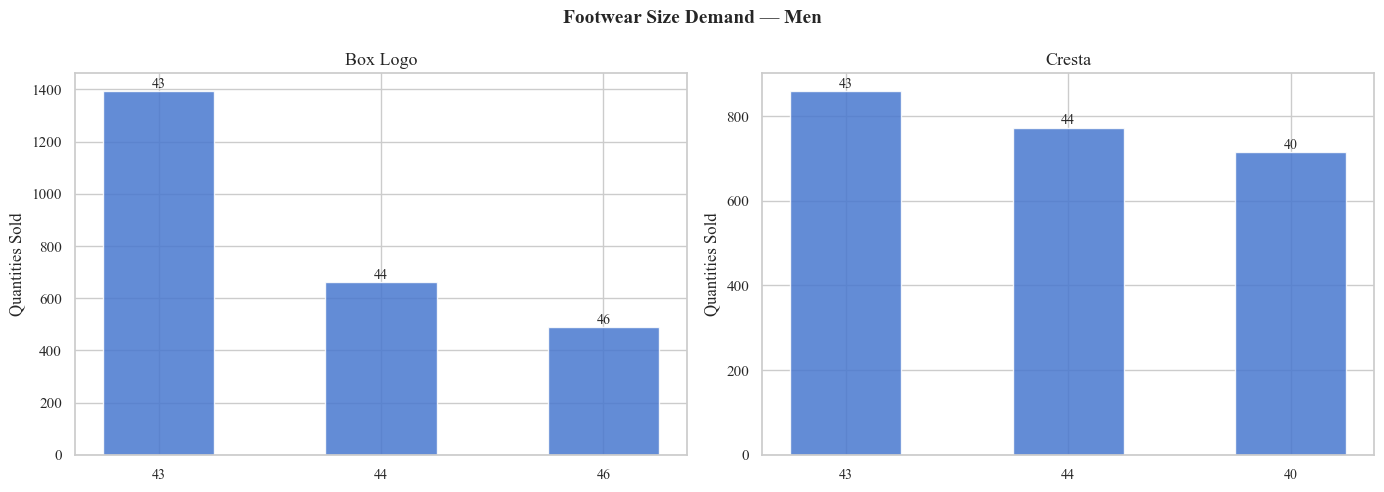

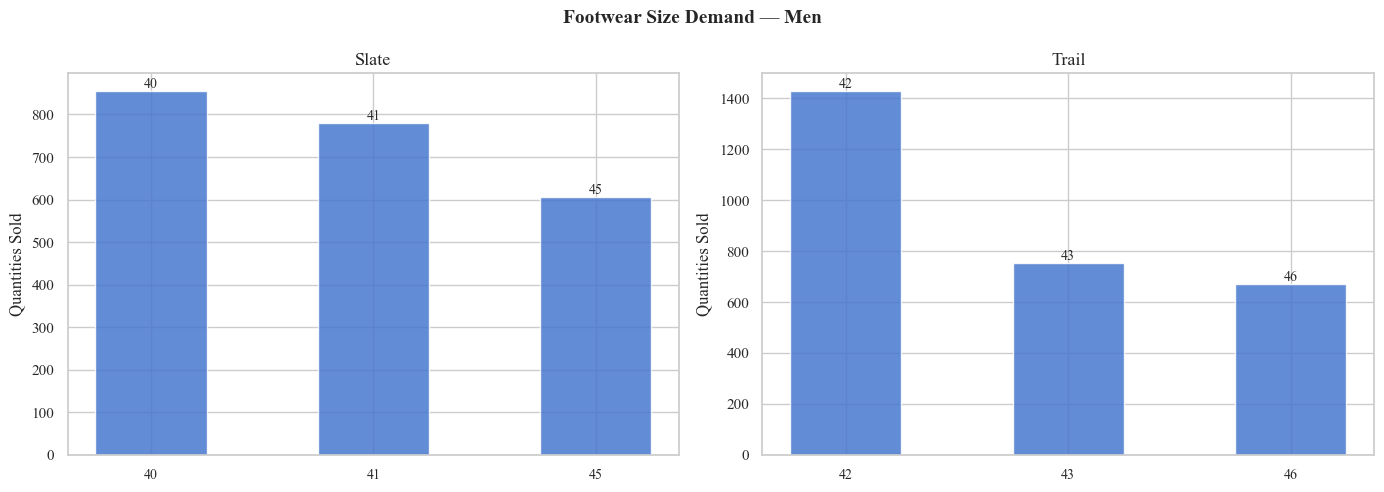

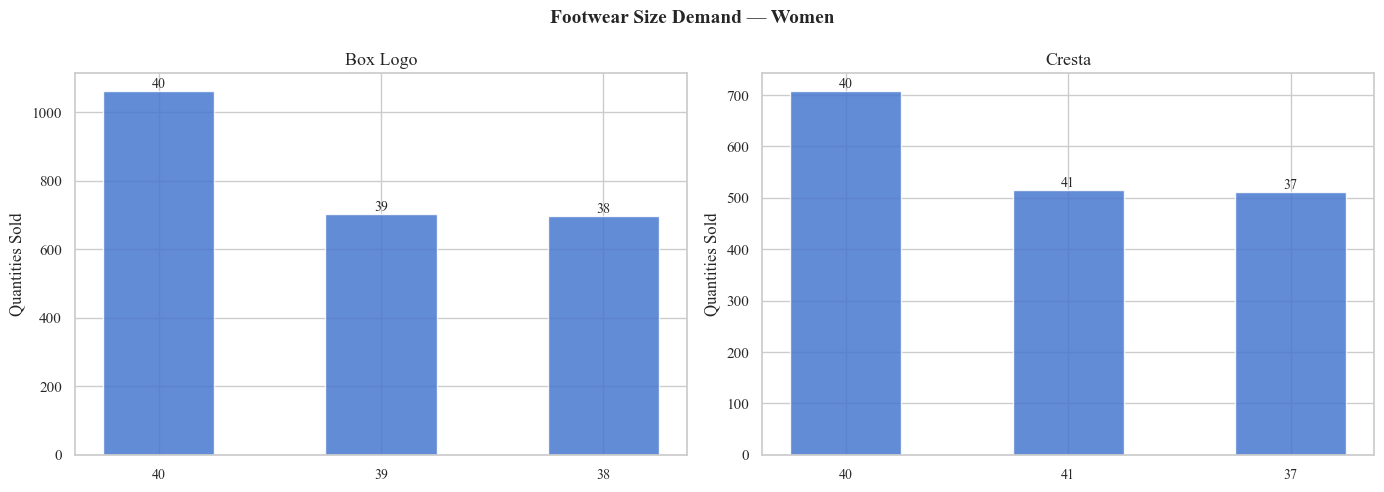

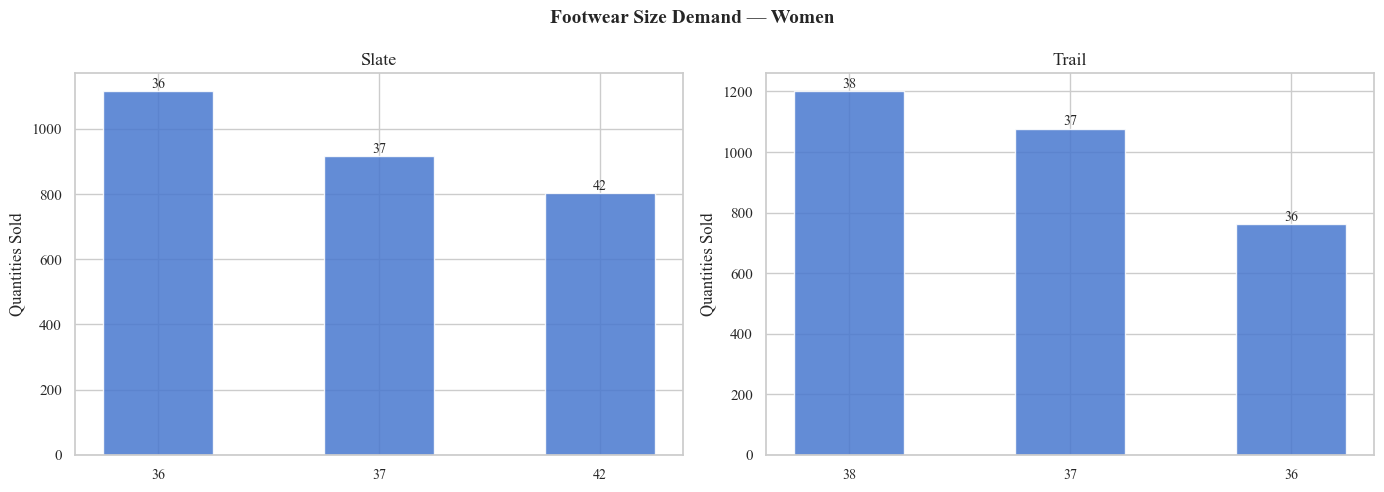

In [12]:
rank_colors = {1: "#4878CF", 2: "#6ACC65", 3: "#D65F5F"}

for sex in ["Men", "Women"]:
    sex_data   = top3_numeric[top3_numeric["sex"] == sex]
    families   = sex_data["collection_family"].unique()

    for i in range(0, len(families), 2):
        batch = families[i:i+2]
        fig, axes = plt.subplots(1, len(batch), figsize=(14, 5))
        if len(batch) == 1:
            axes = [axes]

        for ax, fam in zip(axes, batch):
            subset = sex_data[sex_data["collection_family"] == fam]
            sizes  = subset["size"].unique()
            x      = np.arange(len(sizes))
            width  = 0.5

            bars = ax.bar(x, subset.set_index("size").reindex(sizes)["quantities_sold"].fillna(0),
                          width, color=rank_colors[1], alpha=0.85)
            for bar, sz in zip(bars, sizes):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 1, str(sz),
                        ha="center", va="bottom", fontsize=10)

            ax.set_title(fam, fontsize=13)
            ax.set_xticks(x)
            ax.set_xticklabels(sizes, fontsize=10)
            ax.set_ylabel("Quantities Sold")

        fig.suptitle(f"Footwear Size Demand — {sex}", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.savefig(FIG_PATH + f"h1_numeric_{sex.lower()}_{i//2 + 1}.png", dpi=150, bbox_inches="tight")
        plt.show()

**H1 Findings — Numeric Sizes (Footwear)**

Men's footwear demand concentrates in **42–43** across all collections, with 40–41 as secondary sizes in certain lines.<br>
Women's footwear is led by **38–40** consistently, with 36–37 as secondary across Slate and Trail collections.<br>
Both patterns are consistent with Mediterranean anthropometric norms — smaller foot sizes relative to Northern European markets.

**Inventory recommendation:** Men's footwear stock depth should prioritise 42–43; Women's should prioritise 38–40.<br>
Sizes 36 and 46 show consistently low volume across both sexes — reduce reorder quantities at the extremes.

________

## H2 — Color Preference & Collection Planning

Identifying which colors drive the highest sales volume to guide future sourcing decisions.<br>
Analysed overall first, then cross-tabbed with `season` and `sex`.


In [13]:
color_total = (
    df.groupby("color")["quantities_sold"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
display(color_total)

,color,quantities_sold
0,Bright White,17017
1,Burgundy,16699
2,Caviar,16647
3,Forest Green,16563
4,Olive,16273
5,Orange Tangerine,16247
6,Yellow Sunshine,15744
7,Old Rose,15596
8,Stone Grey,15440
9,Bright Red,15240


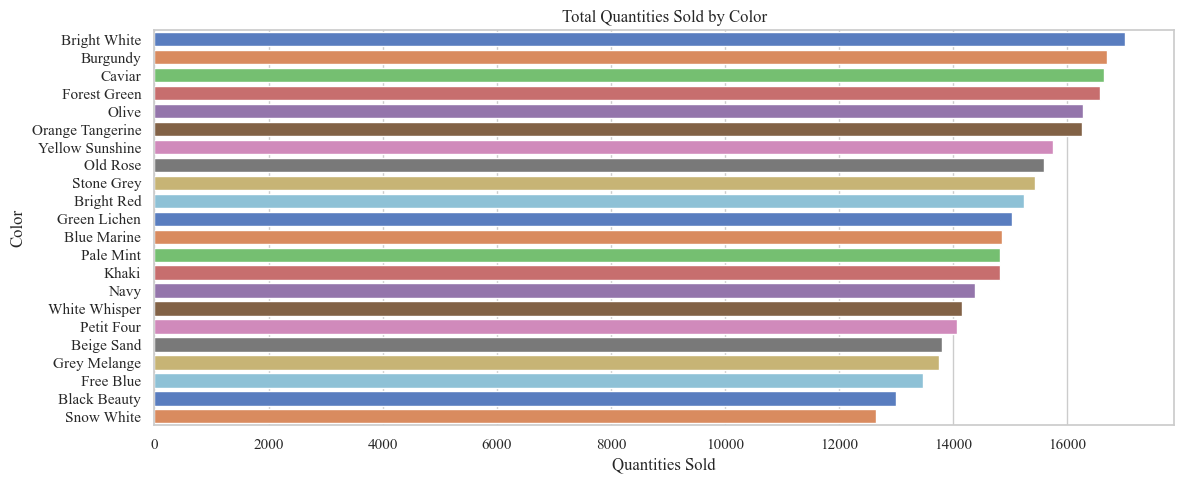

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=color_total, x="quantities_sold", y="color",
            palette="muted", ax=ax)
ax.set_title("Total Quantities Sold by Color")
ax.set_xlabel("Quantities Sold")
ax.set_ylabel("Color")
plt.tight_layout()
plt.savefig(FIG_PATH + "h2_color_overall.png", dpi=150)
plt.show()

The overall ranking above is misleading without a gender breakdown — a color dominating total sales may be driven entirely by one sex.<br>
Recommending a color to the buyer without this context risks stocking it across both Men's and Women's lines when demand exists in only one.<br>
The analysis below splits `quantities_sold` by `color` and `sex` to produce gender-specific color rankings.

In [15]:
color_sex = (
    df.groupby(["color", "sex"])["quantities_sold"]
    .sum()
    .reset_index()
)

color_sex_pivot = color_sex.pivot(index="color", columns="sex", values="quantities_sold").fillna(0)
color_sex_pivot["total"] = color_sex_pivot.sum(axis=1)
color_sex_pivot = color_sex_pivot.sort_values("total", ascending=False).drop(columns="total")
color_sex_pivot["Men_%"]   = (color_sex_pivot["Men"]   / color_sex_pivot.sum(axis=1) * 100).round(1)
color_sex_pivot["Women_%"] = (color_sex_pivot["Women"] / color_sex_pivot.sum(axis=1) * 100).round(1)

display(color_sex_pivot)

sex,Men,Women,Men_%,Women_%
color,,,,
Bright White,10480,6537,61.6000,38.3000
Burgundy,7878,8821,47.2000,52.7000
Caviar,9663,6984,58.0000,41.8000
Forest Green,8465,8098,51.1000,48.7000
Olive,9261,7012,56.9000,42.9000
Orange Tangerine,8804,7443,54.2000,45.7000
Yellow Sunshine,9613,6131,61.1000,38.8000
Old Rose,8994,6602,57.7000,42.2000
Stone Grey,9337,6103,60.5000,39.4000


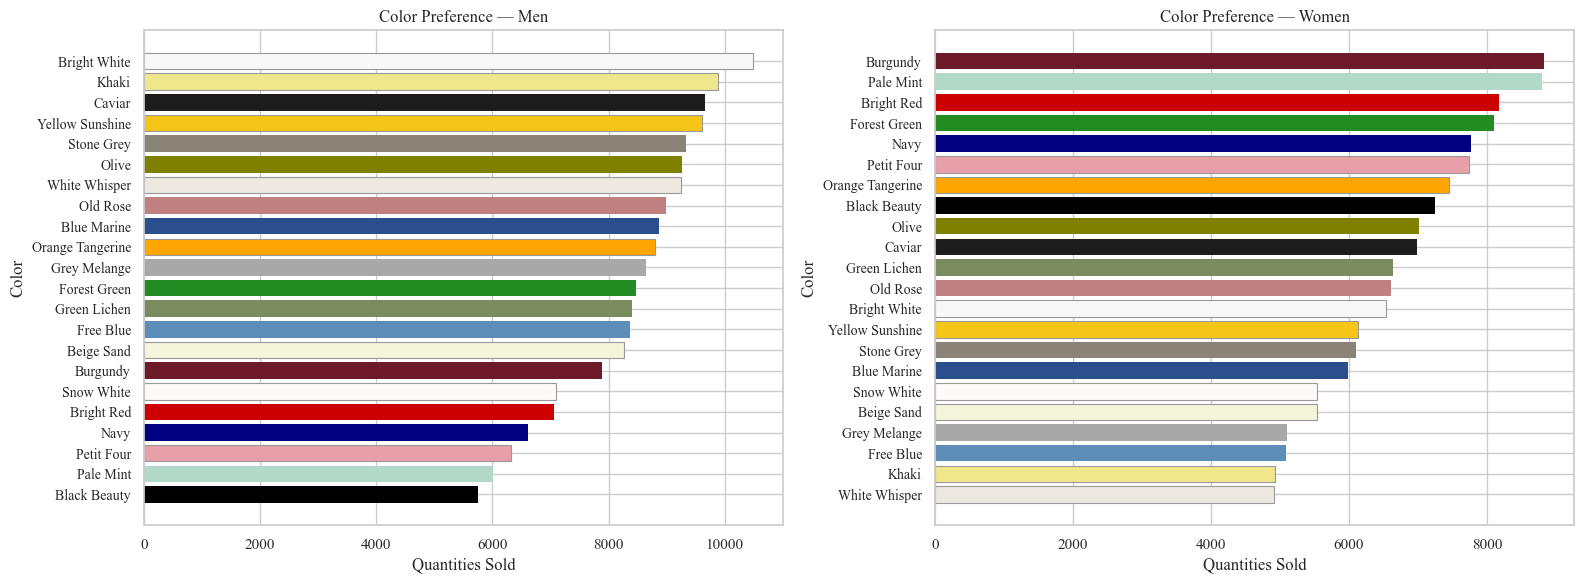

In [20]:
import matplotlib.colors as mcolors

# override only for names that won't auto-resolve
overrides = {
    "Caviar"        : "#1C1C1C",
    "Grey Melange"  : "#A8A8A8",
    "Stone Grey"    : "#8A8478",
    "Old Rose"      : "#C08081",
    "Pale Mint"     : "#B2D8C8",
    "Green Lichen"  : "#7A8C5E",
    "Blue Marine"   : "#2B4E8C",
    "Yellow Sunshine": "#F5C518",
    "Free Blue"     : "#5B8DB8",
    "Blue Klein"    : "#002FA7",
    "White Whisper" : "#EDE8E0",
    "Bright White"  : "#F8F8F8",
}

overrides["Burgundy"]   = "#6D1A2A"
overrides["Bright Red"] = "#CC0000"
overrides["Petit Four"] = "#E8A0A8"   # soft dusty pink (Pantone reference)


def name_to_color(name):
    if name in overrides:
        return overrides[name]
    normalized = name.lower().replace(" ", "")
    if normalized in mcolors.CSS4_COLORS:
        return mcolors.CSS4_COLORS[normalized]
    first_word = name.split()[0].lower()
    if first_word in mcolors.CSS4_COLORS:
        return mcolors.CSS4_COLORS[first_word]
    return "#CCCCCC"

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, sex in zip(axes, ["Men", "Women"]):
    data = (color_sex[color_sex["sex"] == sex]
            .sort_values("quantities_sold", ascending=False)
            .reset_index(drop=True))

    bar_colors  = [name_to_color(c) for c in data["color"]]
    edge_colors = ["#999999" if mcolors.rgb_to_hsv(
                    mcolors.to_rgb(name_to_color(c)))[2] > 0.9
                   else "none" for c in data["color"]]

    ax.barh(data["color"][::-1], data["quantities_sold"][::-1],
            color=bar_colors[::-1], edgecolor=edge_colors[::-1], linewidth=0.8)
    ax.set_title(f"Color Preference — {sex}")
    ax.set_xlabel("Quantities Sold")
    ax.set_ylabel("Color")
    ax.tick_params(axis="y", labelsize=10)

plt.tight_layout()
plt.savefig(FIG_PATH + "h2_color_by_sex.png", dpi=150, bbox_inches="tight")
plt.show()

**H2 Findings — Color Preference by Gender**

Men's top colors are predominantly **neutrals and earth tones** — Bright White, Khaki, Caviar, Yellow Sunshine, Stone Grey.<br>
Women's top colors skew toward **bold and saturated palettes** — Burgundy, Pale Mint, Bright Red, Forest Green, Navy.

This confirms the initial concern: aggregating color sales without a gender split would have produced a misleading ranking.<br>
Bright White ranks first in Men but does not appear in Women's top 5 — a blanket restock recommendation would have been incorrect.

**Sourcing recommendation:**<br>
Men's new collections should continue investing in neutral bases with selective use of accent tones (Yellow Sunshine).<br>
Women's collections should prioritise rich, intentional colors — avoid generic neutrals which are clearly not driving Women's sales.

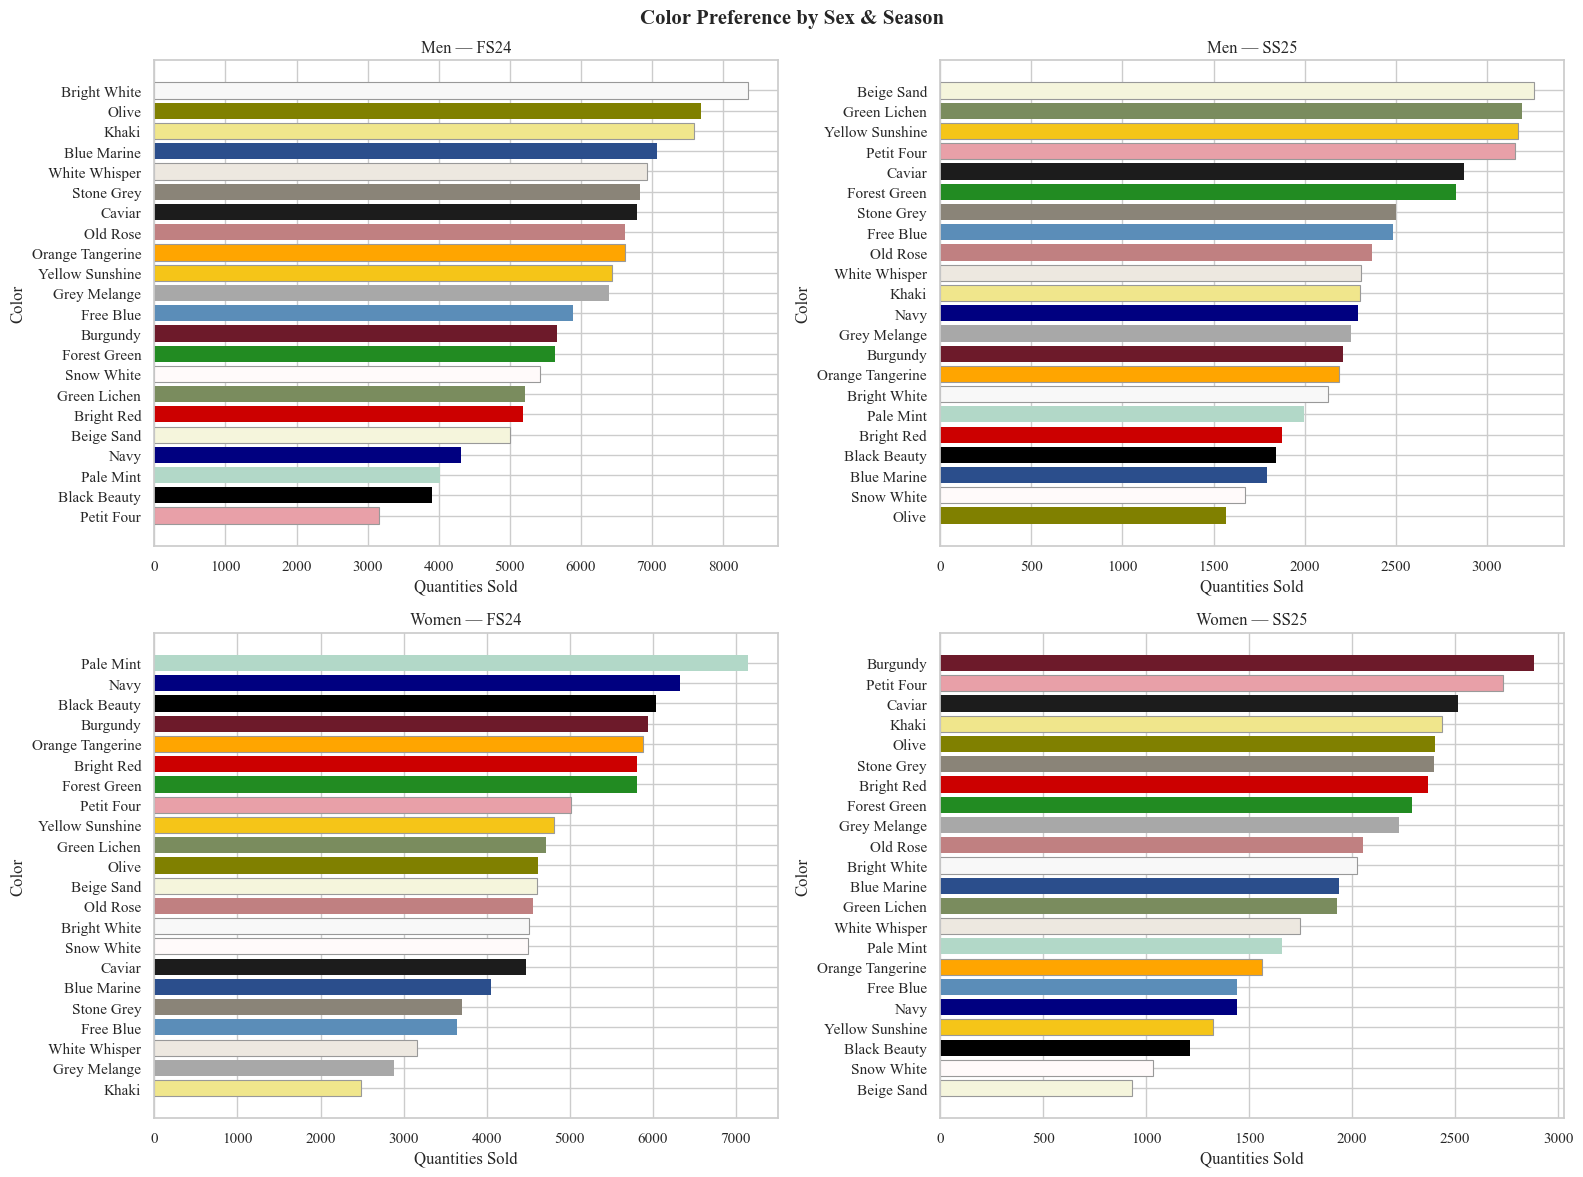

In [21]:
color_season = (
    df.groupby(["color", "season", "sex"])["quantities_sold"]
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for row, sex in enumerate(["Men", "Women"]):
    for col, season in enumerate(["FS24", "SS25"]):
        ax   = axes[row][col]
        data = (color_season[(color_season["sex"] == sex) &
                              (color_season["season"] == season)]
                .sort_values("quantities_sold", ascending=False)
                .reset_index(drop=True))

        bar_colors  = [name_to_color(c) for c in data["color"]]
        edge_colors = ["#999999" if mcolors.rgb_to_hsv(
                        mcolors.to_rgb(name_to_color(c)))[2] > 0.9
                       else "none" for c in data["color"]]

        ax.barh(data["color"][::-1], data["quantities_sold"][::-1],
                color=bar_colors[::-1], edgecolor=edge_colors[::-1], linewidth=0.8)
        ax.set_title(f"{sex} — {season}")
        ax.set_xlabel("Quantities Sold")
        ax.set_ylabel("Color")

plt.suptitle("Color Preference by Sex & Season", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_PATH + "h2_color_by_sex_season.png", dpi=150, bbox_inches="tight")
plt.show()

**H2 Findings — Color Performance by Season**

Seasonal color preferences shift notably between FS24 and SS25, but a subset of colors maintain top-5 positions across both seasons.<br>
For Men, **Caviar** and **Stone Grey** are consistent performers — neutral anchors that transcend seasonal trends.<br>
For Women, **Khaki** and **Burgundy** hold strong across seasons, with Burgundy improving in SS25.<br>
Seasonal leaders (Green Lichen in Men's FS24, Pale Mint in Women's FS24) are trend-driven and should be treated as seasonal bets, not permanent staples.

**Sourcing recommendation:**<br>
Prioritise cross-seasonal colors for core collection depth (Caviar, Stone Grey, Khaki, Burgundy).<br>
Introduce seasonal accent colors in smaller quantities to capture trend demand without overcommitting inventory.

_____
## H3 — Discount Effect on Sales Performance

Testing whether discounted products sell significantly more units than non-discounted ones.<br>
All numeric columns were confirmed non-normal in `00_DataAudit.ipynb` (Shapiro-Wilk p < 0.0001),
so a **Mann-Whitney U test** is used instead of a t-test.<br>
Effect size is measured via **rank-biserial correlation**.

In [22]:
discounted     = df[df["discount"] > 0]["quantities_sold"]
non_discounted = df[df["discount"] == 0]["quantities_sold"]

print(f"Discounted SKUs     : {len(discounted):,}  — mean sold: {discounted.mean():.1f}")
print(f"Non-discounted SKUs : {len(non_discounted):,}  — mean sold: {non_discounted.mean():.1f}")

Discounted SKUs     : 961  — mean sold: 245.0
Non-discounted SKUs : 975  — mean sold: 97.2


In [23]:
stat, p = st.mannwhitneyu(discounted, non_discounted, alternative="two-sided")

n1, n2 = len(discounted), len(non_discounted)
r      = 1 - (2 * stat) / (n1 * n2)   # rank-biserial correlation

print(f"Mann-Whitney U : {stat:,.0f}")
print(f"p-value        : {p:.4f}")
print(f"Effect size r  : {r:.4f}")
print()
if p < 0.05:
    direction = "more" if discounted.mean() > non_discounted.mean() else "fewer"
    print(f"Result: statistically significant — discounted SKUs sell {direction} units (p={p:.4f})")
else:
    print("Result: no statistically significant difference in sales between discounted and non-discounted SKUs.")

Mann-Whitney U : 773,990
p-value        : 0.0000
Effect size r  : -0.6521

Result: statistically significant — discounted SKUs sell more units (p=0.0000)


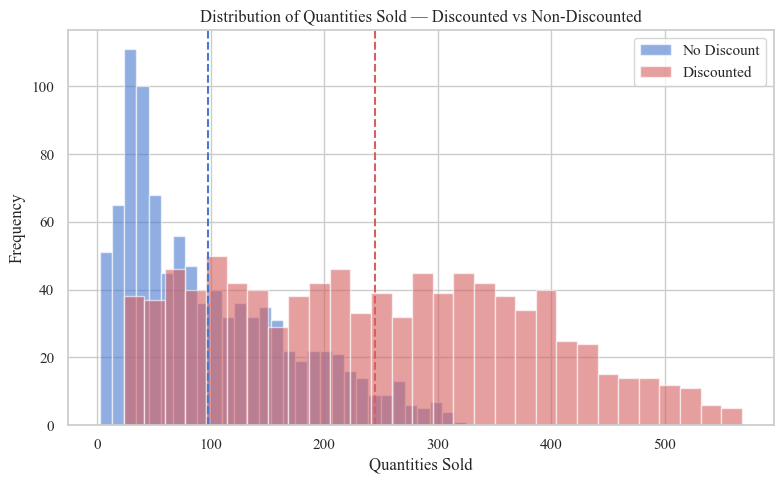

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(non_discounted, bins=30, alpha=0.6, label="No Discount", color="#4878CF")
ax.hist(discounted,     bins=30, alpha=0.6, label="Discounted",  color="#D65F5F")

ax.axvline(non_discounted.mean(), color="#4878CF", linestyle="--", linewidth=1.5)
ax.axvline(discounted.mean(),     color="#D65F5F", linestyle="--", linewidth=1.5)

ax.set_xlabel("Quantities Sold")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Quantities Sold — Discounted vs Non-Discounted")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_PATH + "h3_discount_effect.png", dpi=150)
plt.show()

**H3 Findings — Discount Effect on Sales**

The Mann-Whitney U test confirms a **statistically significant difference** (U = 773,990, p < 0.0001).<br>
Discounted SKUs sold on average **245 units** versus **97 units** for non-discounted — a 2.5x uplift.<br>
The effect size (rank-biserial r = -0.65) indicates a **large practical effect**, not just a statistical one.<br>
The distribution confirms this visually — non-discounted SKUs concentrate below 100 units while discounted SKUs spread uniformly across the full 0–577 range.

**However, causality cannot be assumed from this data alone.**<br>
Discounts may have been applied precisely to slow-moving items to stimulate demand — meaning the discount did not cause high sales, it was a response to low sales risk.<br>
To establish causality, a controlled experiment (A/B test) comparing identical products with and without discount would be required.

**Business recommendation:**<br>
Discounting is clearly associated with higher volume. Apply targeted discounts on mid-performing SKUs with healthy remaining stock to accelerate sell-through before end of season.<br>
Avoid blanket discounting — pair with the dead stock findings from `01_DataCleaning.ipynb` to prioritise which SKUs need intervention.

_________

## Dead Stock

Seven SKUs were flagged in `01_DataCleaning.ipynb` as high-quantity with critically low sell-through (8% vs 53% dataset average).<br>
This section quantifies the dead stock problem across the full dataset and identifies which categories and collections are most exposed.

In [25]:
print(df["sell_through"].describe().round(3).to_string())

low_st = df[df["sell_through"] < 0.2].copy()
print(f"\nSKUs with sell-through < 20%  : {len(low_st):,}  ({len(low_st)/len(df)*100:.1f}% of catalogue)")
print(f"Total units tied up in low ST : {low_st['quantity'].sum():,}")

count   1936.0000
mean       0.5250
std        0.2660
min        0.0450
25%        0.2900
50%        0.5440
75%        0.7530
max        0.9700

SKUs with sell-through < 20%  : 306  (15.8% of catalogue)
Total units tied up in low ST : 85,902


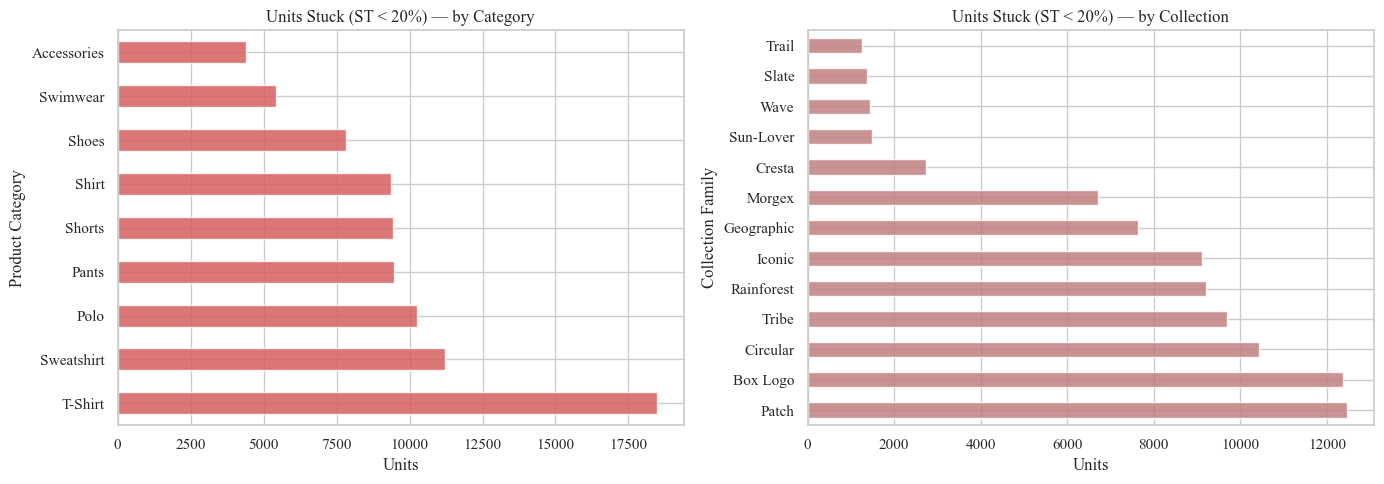

,sku_count,units_stuck
product_category,,
T-Shirt,61,18472
Sweatshirt,42,11210
Polo,36,10270
Pants,35,9483
Shorts,37,9433
Shirt,33,9378
Shoes,28,7817
Swimwear,19,5427
Accessories,15,4412


,sku_count,units_stuck
collection_family,,
Patch,42,12466
Box Logo,46,12369
Circular,37,10428
Tribe,32,9698
Rainforest,38,9197
Iconic,30,9118
Geographic,26,7628
Morgex,26,6710
Cresta,10,2743


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# by product category
cat_st = (low_st.groupby("product_category")
          .agg(sku_count=("name", "count"), units_stuck=("quantity", "sum"))
          .sort_values("units_stuck", ascending=False))

cat_st["units_stuck"].plot(kind="barh", ax=axes[0], color="#D65F5F", alpha=0.85)
axes[0].set_title("Units Stuck (ST < 20%) — by Category")
axes[0].set_xlabel("Units")
axes[0].set_ylabel("Product Category")

# by collection family
col_st = (low_st.groupby("collection_family")
          .agg(sku_count=("name", "count"), units_stuck=("quantity", "sum"))
          .sort_values("units_stuck", ascending=False))

col_st["units_stuck"].plot(kind="barh", ax=axes[1], color="#C08081", alpha=0.85)
axes[1].set_title("Units Stuck (ST < 20%) — by Collection")
axes[1].set_xlabel("Units")
axes[1].set_ylabel("Collection Family")

plt.tight_layout()
plt.savefig(FIG_PATH + "dead_stock_breakdown.png", dpi=150)
plt.show()

display(cat_st)
display(col_st)

**Dead Stock Findings**

**15.8% of the catalogue** (306 SKUs) has a sell-through below 20%, with **85,902 units tied up** in slow-moving inventory.

By category, **T-Shirts carry the largest dead stock exposure** (~18,000 units), followed by Sweatshirts and Polos.<br>
Accessories and Swimwear are the least exposed — smaller unit volumes and more targeted purchasing.

By collection, **Patch and Box Logo** are the most critical (~12,000 units each), followed by Circular and Tribe.<br>
Trail, Slate, Wave and Sun-Lover show minimal dead stock — likely smaller, more controlled collections.

**The problem is not spread evenly — it is concentrated.**<br>
T-Shirts in Patch and Box Logo collections represent the highest priority for intervention.

**Business recommendation:**<br>
Apply immediate targeted discounts to T-Shirts in Patch and Box Logo to accelerate sell-through before next season.<br>
H3 confirmed discounting produces a 2.5x sales uplift — this is the most evidence-backed lever available.<br>
Review reorder quantities on T-Shirts and flagship collections — the current purchasing model is systematically over-ordering in these segments.<br>
Consider introducing a sell-through KPI threshold (e.g. 40% minimum by mid-season) to trigger automatic discount rules.

_____
## EDA Summary

In [28]:
summary = {
    "H1 — Size (Apparel)"   : "Men: M–XL core, Women: XS–M tops / mixed bottoms. Size demand varies by collection.",
    "H1 — Size (Footwear)"  : "Men: 42–43 dominant. Women: 38–40 dominant. Reduce orders at extremes (36, 46).",
    "H2 — Color (Overall)"  : "Men prefer neutrals (Bright White, Khaki, Caviar). Women prefer bold tones (Burgundy, Bright Red).",
    "H2 — Color (Season)"   : "Caviar & Stone Grey cross-seasonal for Men. Khaki & Burgundy cross-seasonal for Women.",
    "H3 — Discount Effect"  : "Significant uplift confirmed (p<0.0001, r=-0.65). Discounted SKUs sell 2.5x more on average.",
    "H3 — Causality Warning": "Correlation only — discounts may target slow movers. A/B test required to confirm causality.",
    "Dead Stock"            : "306 SKUs (15.8%) below 20% sell-through. 85,902 units stuck. T-Shirts, Patch & Box Logo most exposed.",
    "Recommendation"        : "Discount T-Shirts in Patch/Box Logo immediately. Cap reorders in flagship collections. Set mid-season ST KPI.",
}

print("══ EDA SUMMARY ════════════════════════════════════════════════════")
for key, val in summary.items():
    print(f"\n  {key}")
    print(f"  → {val}")

══ EDA SUMMARY ════════════════════════════════════════════════════

  H1 — Size (Apparel)
  → Men: M–XL core, Women: XS–M tops / mixed bottoms. Size demand varies by collection.

  H1 — Size (Footwear)
  → Men: 42–43 dominant. Women: 38–40 dominant. Reduce orders at extremes (36, 46).

  H2 — Color (Overall)
  → Men prefer neutrals (Bright White, Khaki, Caviar). Women prefer bold tones (Burgundy, Bright Red).

  H2 — Color (Season)
  → Caviar & Stone Grey cross-seasonal for Men. Khaki & Burgundy cross-seasonal for Women.

  H3 — Discount Effect
  → Significant uplift confirmed (p<0.0001, r=-0.65). Discounted SKUs sell 2.5x more on average.

  H3 — Causality Warning
  → Correlation only — discounts may target slow movers. A/B test required to confirm causality.

  Dead Stock
  → 306 SKUs (15.8%) below 20% sell-through. 85,902 units stuck. T-Shirts, Patch & Box Logo most exposed.

  Recommendation
  → Discount T-Shirts in Patch/Box Logo immediately. Cap reorders in flagship collections.